# 06b · Selección del tamaño de ventana para EPCA — versión MENSUAL
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning

Analogo a `06a_seleccion_ventana_epca_v2.ipynb`, pero usando
`data/processed/*_mensual.csv` (208 observaciones, n/p ≈ 12.2 en la
version transformada, vs. 4.5 en trimestral).

**Hipótesis a verificar en este notebook:**
1. ¿La mayor cantidad de observaciones permite ventanas de duración
   calendario más corta (ej. 2-3 años) sin caer en zona degenerada?
2. ¿El dataset mensual alcanza a cubrir la crisis financiera global
   2008-2009, ausente por completo en la version trimestral?

**No modifica ningún archivo de `data/processed/` -- solo lee.**

## 1. Librerías y carga de datos

In [1]:
import os
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_transf = pd.read_csv('data/processed/dataset_estandarizado_mensual.csv',
                         index_col=0, parse_dates=True)
df_niveles = pd.read_csv('data/processed/dataset_niveles_estandarizado_mensual.csv',
                          index_col=0, parse_dates=True)

print(f'Transformado: {df_transf.shape[0]} meses x {df_transf.shape[1]} variables')
print(f'Niveles:      {df_niveles.shape[0]} meses x {df_niveles.shape[1]} variables')
print(f'Periodo: {df_transf.index.min().strftime("%Y-%m")} a {df_transf.index.max().strftime("%Y-%m")}')

EPISODIOS = {
    'Crisis financiera global': ('2008-07-01', '2009-06-30'),
    'Colapso commodities': ('2014-06-01', '2016-03-31'),
    'Kuczynski / Odebrecht': ('2016-07-01', '2018-03-31'),
    'Taper tantrum': ('2013-04-01', '2013-12-31'),
    'Pandemia COVID-19': ('2020-01-01', '2020-09-30'),
}
print()
print('Cobertura de episodios dentro del rango de datos:')
for nombre, (ini, fin) in EPISODIOS.items():
    cubierto = (pd.Timestamp(ini) >= df_transf.index.min()) and (pd.Timestamp(ini) <= df_transf.index.max())
    print(f'  {nombre}: {"SI" if cubierto else "NO"} cubierto')

Transformado: 208 meses x 17 variables
Niveles:      209 meses x 19 variables
Periodo: 2007-02 a 2025-12

Cobertura de episodios dentro del rango de datos:
  Crisis financiera global: SI cubierto
  Colapso commodities: SI cubierto
  Kuczynski / Odebrecht: SI cubierto
  Taper tantrum: SI cubierto
  Pandemia COVID-19: SI cubierto


## 2. Función de análisis de sensibilidad (idéntica lógica que en 06a, ajustada a meses)

In [2]:
def analizar_ventanas(df, tamanos_ventana, paso, componente_interes=0, n_componentes=3):
    resultados = {}
    for w in tamanos_ventana:
        fechas_centro = []
        cargas_series = []
        inicio = 0
        while inicio + w <= len(df):
            ventana = df.iloc[inicio:inicio + w]
            ventana_std = StandardScaler().fit_transform(ventana)
            pca = PCA(n_components=min(n_componentes, ventana.shape[1]), random_state=42)
            pca.fit(ventana_std)
            carga = pca.components_[componente_interes]
            fechas_centro.append(ventana.index[w // 2])
            cargas_series.append(carga)
            inicio += paso
        cargas_alineadas = [cargas_series[0]]
        for c in cargas_series[1:]:
            corr_directa = np.corrcoef(c, cargas_alineadas[-1])[0, 1]
            cargas_alineadas.append(c if corr_directa >= 0 else -c)
        estabilidad = [
            np.corrcoef(cargas_alineadas[i], cargas_alineadas[i + 1])[0, 1]
            for i in range(len(cargas_alineadas) - 1)
        ]
        fechas_estabilidad = fechas_centro[1:]
        resultados[w] = {'fechas': fechas_estabilidad, 'estabilidad': estabilidad, 'n_ventanas': len(cargas_series)}
    return resultados

## 3. Grilla de tamaños de ventana (en MESES)

- **Mínimo:** 24 meses (2 años) -- lo que originalmente se quería probar
  y que en trimestral era matemáticamente inviable (n=8 < p=16). En
  mensual, n=24 > p=17 (razón 1.4), ya no degenerado, aunque todavía por
  debajo de la regla práctica de 5x.
- **Máximo:** 96 meses (8 años) -- razón n/p ≈ 5.6, ya dentro de la regla
  práctica, y todavía por debajo de la duración típica de un ciclo
  financiero completo (Drehmann et al., 2012: 8-20 años).
- **Paso:** 3 meses (trimestral), para mantener el costo computacional
  razonable sin perder demasiada resolución. Ajustable.

In [3]:
TAMANOS_VENTANA_MESES = [24, 36, 48, 60, 72, 96]
PASO_MESES = 3

resultados_transf = analizar_ventanas(df_transf, TAMANOS_VENTANA_MESES, paso=PASO_MESES, componente_interes=0)

resumen = []
p = df_transf.shape[1]
for w, r in resultados_transf.items():
    estab = np.array(r['estabilidad'])
    umbral = estab.mean() - estab.std()
    n_caidas = int((estab < umbral).sum())
    resumen.append({
        'ventana_meses': w,
        'ventana_anios': round(w / 12, 1),
        'n_p_ratio': round(w / p, 1),
        'n_ventanas_generadas': r['n_ventanas'],
        'estabilidad_promedio': round(estab.mean(), 3),
        'estabilidad_std': round(estab.std(), 3),
        'n_caidas_detectadas': n_caidas,
    })

df_resumen = pd.DataFrame(resumen)
df_resumen

,ventana_meses,ventana_anios,n_p_ratio,n_ventanas_generadas,estabilidad_promedio,estabilidad_std,n_caidas_detectadas
0,24,2.0,1.4,62,0.871,0.184,8
1,36,3.0,2.1,58,0.939,0.114,5
2,48,4.0,2.8,54,0.934,0.178,3
3,60,5.0,3.5,50,0.972,0.070,4
4,72,6.0,4.2,46,0.976,0.068,3
5,96,8.0,5.6,38,0.980,0.055,3


## 4. Trade-off estabilidad vs. sensibilidad (mensual)

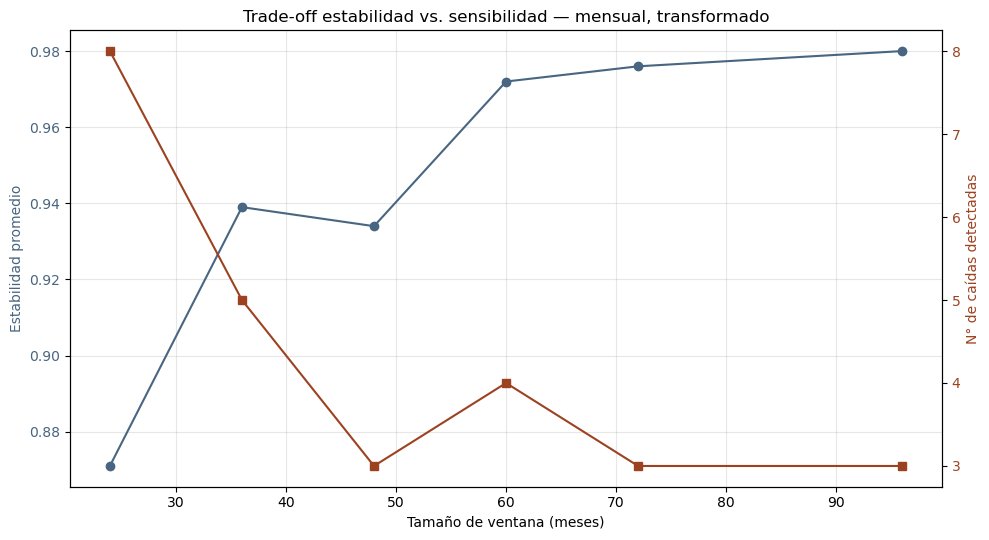

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))
color1 = '#486581'
ax1.plot(df_resumen['ventana_meses'], df_resumen['estabilidad_promedio'], marker='o', color=color1)
ax1.set_xlabel('Tamaño de ventana (meses)')
ax1.set_ylabel('Estabilidad promedio', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = '#9c4221'
ax2.plot(df_resumen['ventana_meses'], df_resumen['n_caidas_detectadas'], marker='s', color=color2)
ax2.set_ylabel('N° de caídas detectadas', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off estabilidad vs. sensibilidad — mensual, transformado')
fig.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/06b_tradeoff_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Validación externa (mensual) — con los 5 episodios, incluyendo 2008-2009

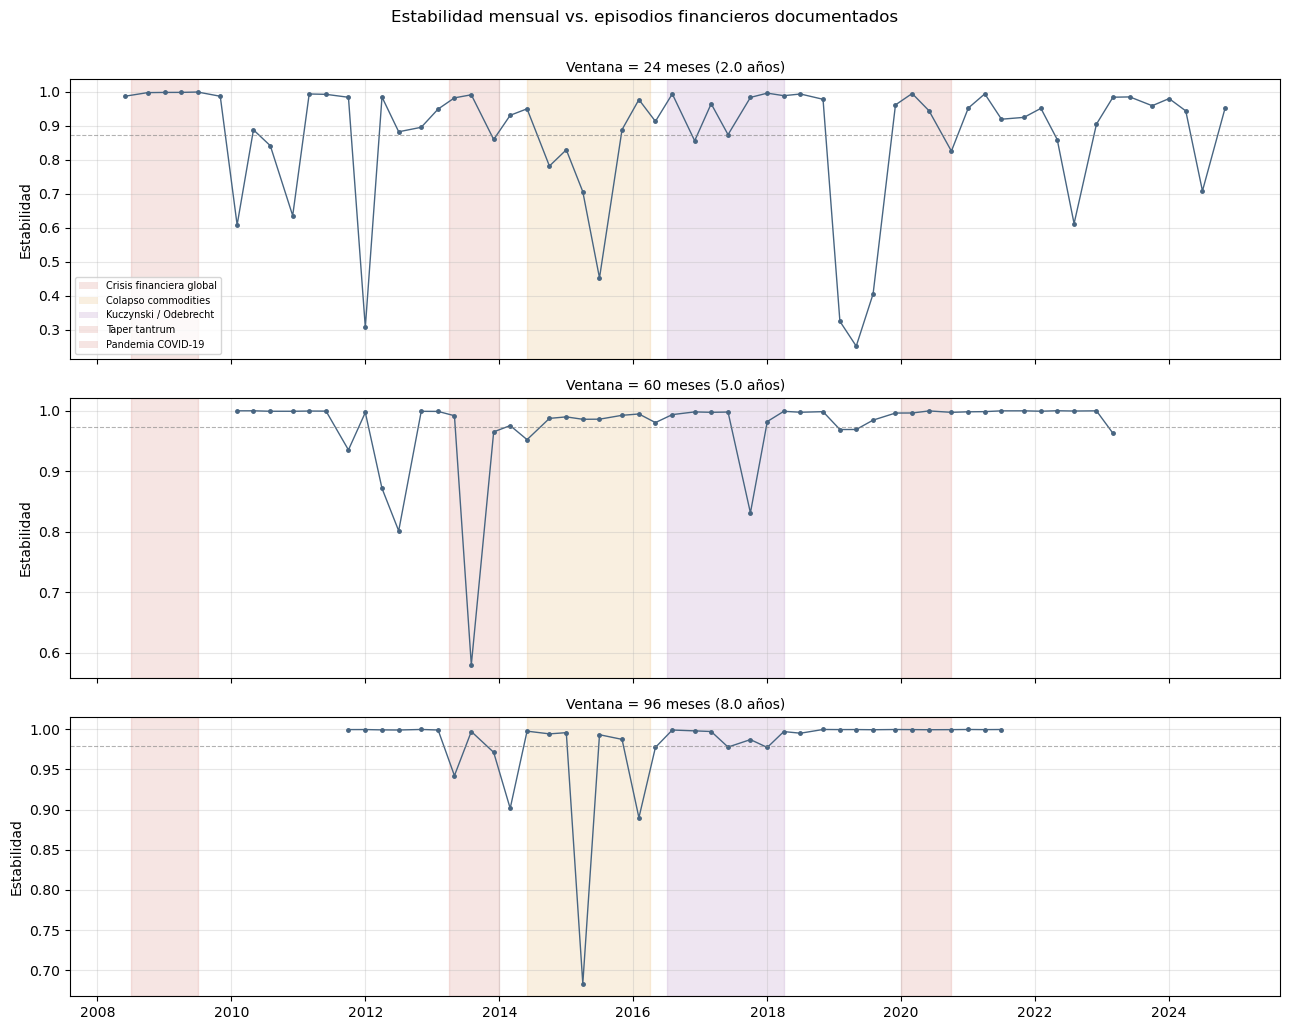

In [5]:
tamanos_a_graficar = [TAMANOS_VENTANA_MESES[0], TAMANOS_VENTANA_MESES[len(TAMANOS_VENTANA_MESES)//2], TAMANOS_VENTANA_MESES[-1]]

fig, axes = plt.subplots(len(tamanos_a_graficar), 1, figsize=(13, 3.4 * len(tamanos_a_graficar)), sharex=True)

colores_episodios = {'Crisis financiera global': '#c0392b', 'Colapso commodities': '#d68910',
                      'Kuczynski / Odebrecht': '#7d3c98', 'Taper tantrum': '#c0392b',
                      'Pandemia COVID-19': '#c0392b'}

for ax, w in zip(axes, tamanos_a_graficar):
    r = resultados_transf[w]
    ax.plot(r['fechas'], r['estabilidad'], marker='o', markersize=2.5, linewidth=1, color='#486581')
    ax.axhline(np.mean(r['estabilidad']), color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    for nombre, (ini, fin) in EPISODIOS.items():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color=colores_episodios[nombre], alpha=0.13)
    ax.set_title(f'Ventana = {w} meses ({w/12:.1f} años)', fontsize=10)
    ax.set_ylabel('Estabilidad')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
nombres_unicos = list(dict.fromkeys(EPISODIOS.keys()))
leyenda = [Patch(facecolor=colores_episodios[n], alpha=0.13, label=n) for n in nombres_unicos]
axes[0].legend(handles=leyenda, loc='lower left', fontsize=7)

plt.suptitle('Estabilidad mensual vs. episodios financieros documentados', y=1.005)
plt.tight_layout()
plt.savefig('reports/figures/06b_validacion_episodios_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparación directa trimestral vs. mensual

Resumen lado a lado para decidir con qué frecuencia continuar en
`06_epca.ipynb`.

In [6]:
try:
    df_resumen_trimestral = pd.read_csv('data/results/06a_seleccion_ventana_resumen.csv')
    df_resumen_trimestral = df_resumen_trimestral[df_resumen_trimestral['dataset'] == 'transformado_estandarizado']
    print('--- Trimestral (transformado) ---')
    print(df_resumen_trimestral[['ventana_trimestres', 'ventana_anios', 'estabilidad_promedio', 'estabilidad_std']])
except FileNotFoundError:
    print('Corre primero 06a_seleccion_ventana_epca_v2.ipynb para tener la comparacion completa.')

print()
print('--- Mensual (transformado) ---')
print(df_resumen[['ventana_meses', 'ventana_anios', 'n_p_ratio', 'estabilidad_promedio', 'estabilidad_std']])

--- Trimestral (transformado) ---
   ventana_trimestres  ventana_anios  estabilidad_promedio  estabilidad_std
0                  20            5.0                 0.885            0.228
1                  24            6.0                 0.921            0.149
2                  28            7.0                 0.913            0.179
3                  32            8.0                 0.895            0.214
4                  36            9.0                 0.898            0.224
5                  40           10.0                 0.922            0.147

--- Mensual (transformado) ---
   ventana_meses  ventana_anios  n_p_ratio  estabilidad_promedio  \
0             24            2.0        1.4                 0.871   
1             36            3.0        2.1                 0.939   
2             48            4.0        2.8                 0.934   
3             60            5.0        3.5                 0.972   
4             72            6.0        4.2                 0.9

## 7. Guardar resultados

In [7]:
os.makedirs('data/results', exist_ok=True)
df_resumen['dataset'] = 'transformado_estandarizado_mensual'
df_resumen.to_csv('data/results/06b_seleccion_ventana_resumen_mensual.csv', index=False)
print('Guardado: data/results/06b_seleccion_ventana_resumen_mensual.csv')

Guardado: data/results/06b_seleccion_ventana_resumen_mensual.csv
